# Etapa 3 — Aplicação de Algoritmos de Agrupamento

Partindo da base já tratada (Etapa 1) e dos atributos selecionados na Etapa 2, aqui aplicamos algoritmos de clusterização sobre os restaurantes do iFood.


In [1]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

SEED = 42

METRICAS = {'Euclidiana': 'euclidean', 'Manhattan': 'manhattan', 'Cosseno': 'cosine'}

PARES = [('delivery_fee', 'delivery_time'),
         ('price_encoded', 'rating'),
         ('minimumOrderValue', 'rating')]


def scatter_par(ax, feat_df, labels, fx, fy):
    for u in np.unique(labels):
        m = labels == u
        cor = 'lightgray' if u == -1 else None
        nome = 'ruído' if u == -1 else f'C{u}'
        ax.scatter(feat_df[fx].values[m], feat_df[fy].values[m],
                   s=8, alpha=0.4, label=nome, c=cor)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)


def plot_pares(feat_df, labels, titulo):
    fig, axes = plt.subplots(1, len(PARES), figsize=(6 * len(PARES), 5))
    for ax, (fx, fy) in zip(axes, PARES):
        scatter_par(ax, feat_df, labels, fx, fy)
        ax.set_title(f'{fx} × {fy}')
    axes[0].legend(markerscale=2, fontsize=7, loc='best')
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Carregamento dos dados

Lemos o CSV gerado na Etapa 1 (já limpo e com as variáveis numéricas padronizadas).

In [3]:
csv_path = _root / 'data' / 'processed' / 'restaurants_preprocessed.csv'
df = pd.read_csv(csv_path)

print(f"{df.shape[0]:,} restaurantes × {df.shape[1]} colunas")
df.head()

394,192 restaurantes × 8 colunas


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.659290,-1.251447,-0.562502,-1.094339
1,Açaí,CHEAPEST,0,5300108,0.292185,0.921866,-0.562502,-1.094339
2,Bebidas,MODERATE,0,5300108,1.243660,1.497155,-1.230091,-1.094339
3,Carnes,CHEAPEST,0,5300108,2.314070,1.049708,0.772676,-1.094339
4,Brasileira,CHEAPEST,0,5300108,1.243660,0.730104,0.772676,-1.094339


## Seleção de atributos (recap da Etapa 2)

Reaplicamos aqui as decisões fechadas na Etapa 2:

- removemos `availableForScheduling` (pouca representatividade, ~0,4%);
- transformamos `price_range` em `price_encoded` (mapeamento ordinal de 1 a 5);
- agrupamos `category` em `category_grouped` (top 10 + *Outros*) — usada **apenas** para interpretação, não entra no modelo.

Os atributos usados no agrupamento são as 5 variáveis numéricas, repadronizadas com `StandardScaler` (para colocar `price_encoded` na mesma escala das demais).

In [4]:
mapa_precos = {'CHEAPEST': 1, 'CHEAP': 2, 'MODERATE': 3, 'EXPENSIVE': 4, 'MOST_EXPENSIVE': 5}
top_10_categorias = df['category'].value_counts().nlargest(10).index

df_feat = df.copy()
df_feat['price_encoded'] = df_feat['price_range'].map(mapa_precos)
df_feat['category_grouped'] = df_feat['category'].where(
    df_feat['category'].isin(top_10_categorias), 'Outros'
)

col_modelo = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating', 'price_encoded']
df_feat = df_feat.dropna(subset=col_modelo).reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(df_feat[col_modelo])

print(f"Matriz de atributos: {X.shape[0]:,} linhas × {X.shape[1]} colunas")
print("Atributos:", col_modelo)

Matriz de atributos: 394,192 linhas × 5 colunas
Atributos: ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating', 'price_encoded']


## Amostragem

A base tem ~390 mil restaurantes. O agrupamento hierárquico tem custo de memória O(n²) (a matriz de distâncias de 390 mil pontos é inviável) e as matrizes de distância da Parte 1 também crescem ao quadrado. Por isso trabalhamos com uma **amostra aleatória de 5.000 restaurantes** (mesma amostra da Etapa 2, `random_state=42`), garantindo reprodutibilidade e comparações sobre os mesmos pontos.

Para **visualizar** os clusters usamos a abordagem **feature-a-feature**: plotamos os pontos em pares de features reais (em z-score), coloridos pelo cluster. Como são 5 features, nenhum gráfico 2D mostra todas de uma vez; então usamos três pares que, juntos, cobrem as cinco: `delivery_fee × delivery_time` (logística), `price_encoded × rating` (preço × avaliação) e `minimumOrderValue × rating`. Features discretas (como `price_encoded`) aparecem como faixas no eixo.

In [5]:
N = 5000
rng = np.random.default_rng(SEED)
idx = rng.choice(len(df_feat), size=N, replace=False)

X_s = X[idx]
X_df = pd.DataFrame(X_s, columns=col_modelo)
info_s = df_feat.iloc[idx][['category_grouped', 'price_range', 'price_encoded']].reset_index(drop=True)

print(f"Amostra: {X_s.shape[0]:,} restaurantes × {X_s.shape[1]} features")

Amostra: 5,000 restaurantes × 5 features


# Parte 1 — Métricas de similaridade e dissimilaridade

Antes de agrupar é preciso definir **como medir a distância entre dois restaurantes**. Testamos três métricas clássicas:

| Métrica | Fórmula (entre $a$ e $b$) | O que captura |
|---|---|---|
| **Euclidiana** (L2) | $\sqrt{\sum_i (a_i-b_i)^2}$ | distância "em linha reta"; penaliza muito diferenças grandes |
| **Manhattan** (L1) | $\sum_i \lvert a_i-b_i \rvert$ | soma das diferenças por eixo; menos sensível a valores extremos |
| **Cosseno** | $1 - \dfrac{a\cdot b}{\lVert a\rVert\,\lVert b\rVert}$ | diferença de *orientação* (ângulo), ignora a magnitude |

Para visualizar o efeito de cada uma, calculamos a matriz de distâncias entre 300 restaurantes da amostra e plotamos como mapa de calor (quanto mais escuro, mais parecidos).

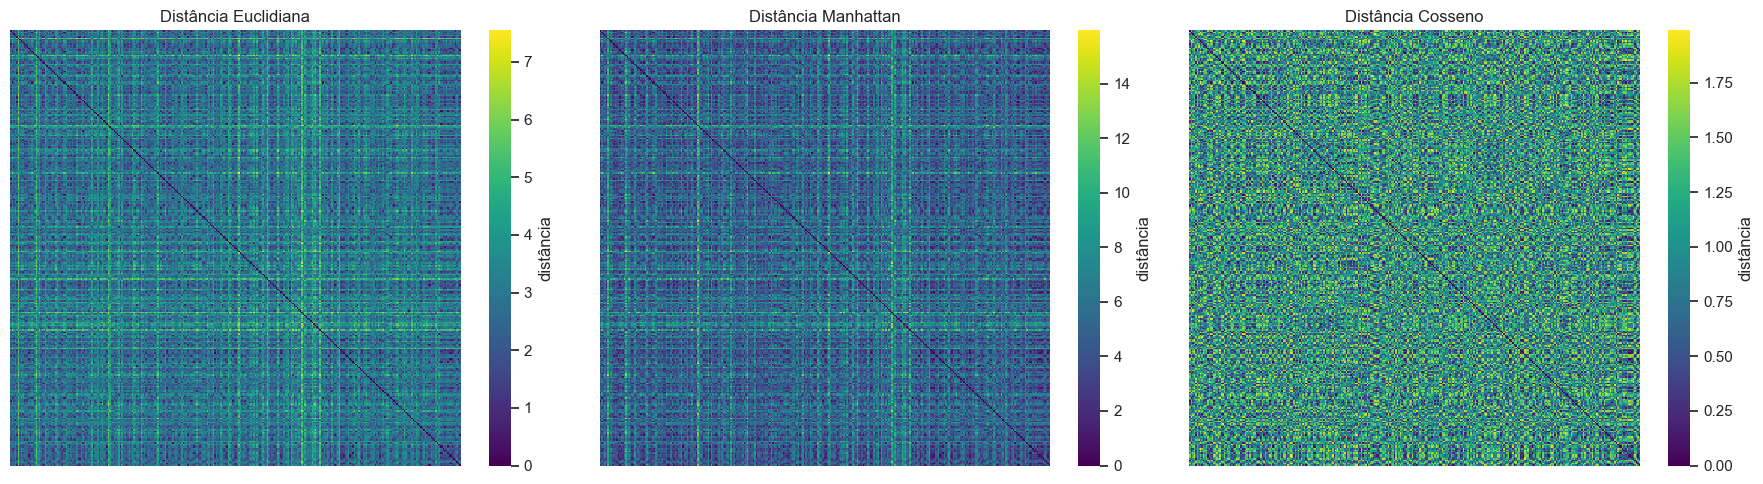

In [6]:
sub = X_s[:300]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, m) in zip(axes, METRICAS.items()):
    D = pairwise_distances(sub, metric=m)
    sns.heatmap(D, ax=ax, cmap='viridis', cbar_kws={'label': 'distância'})
    ax.set_title(f'Distância {nome}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [7]:
# Estatísticas das distâncias par-a-par (1.000 pontos) para comparar as escalas
resumo = {}
for nome, m in METRICAS.items():
    D = pairwise_distances(X_s[:1000], metric=m)
    iu = np.triu_indices_from(D, k=1)
    d = D[iu]
    resumo[nome] = {'mínima': d.min(), 'média': d.mean(), 'máxima': d.max(), 'desvio': d.std()}

pd.DataFrame(resumo).T.round(3)

,mínima,média,máxima,desvio
Euclidiana,0.0,3.005,7.895,1.047
Manhattan,0.0,5.288,15.953,2.213
Cosseno,0.0,0.996,1.997,0.467


**Leitura.** Euclidiana e Manhattan produzem padrões parecidos (ambas medem dissimilaridade pela diferença dos valores), mudando só a escala — Manhattan dá valores maiores por somar as diferenças sem elevar ao quadrado. O Cosseno gera um padrão bem diferente: como nossos atributos são contínuos e já centrados (média ≈ 0), o ângulo entre vetores diz pouco sobre o "perfil" do restaurante, e duas observações próximas em valor podem ficar distantes em cosseno.

**Decisão.** Adotamos a **Euclidiana** como métrica de referência (é a mais natural para atributos numéricos padronizados e é a única suportada pelo K-Means), mas levamos as três para os testes de clusterização hierárquica e DBSCAN, onde dá para trocar a métrica.

# Parte 2 — Métodos de clusterização

Testamos três famílias de algoritmos sobre a mesma amostra:

- **K-Means** — particional, divide os dados em *k* grupos minimizando a distância (euclidiana) ao centróide;
- **Hierárquico/Aglomerativo** — constrói uma árvore de fusões (dendrograma); aqui dá para variar a métrica;
- **DBSCAN** — baseado em densidade, encontra regiões densas e marca o resto como ruído.

## 2.1 K-Means (particional)

O K-Means usa intrinsecamente a distância **euclidiana**. Como ponto de partida usamos `k = 4` (a escolha formal de *k* via Elbow/Silhouette entra na próxima parte da etapa). Rodamos com `random_state=42` e `n_init=10`.

In [8]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
lab_kmeans = kmeans.fit_predict(X_s)

print("Tamanho de cada cluster:")
print(pd.Series(lab_kmeans).value_counts().sort_index().rename('restaurantes'))

Tamanho de cada cluster:
0    1074
1    1752
2     781
3    1393
Name: restaurantes, dtype: int64


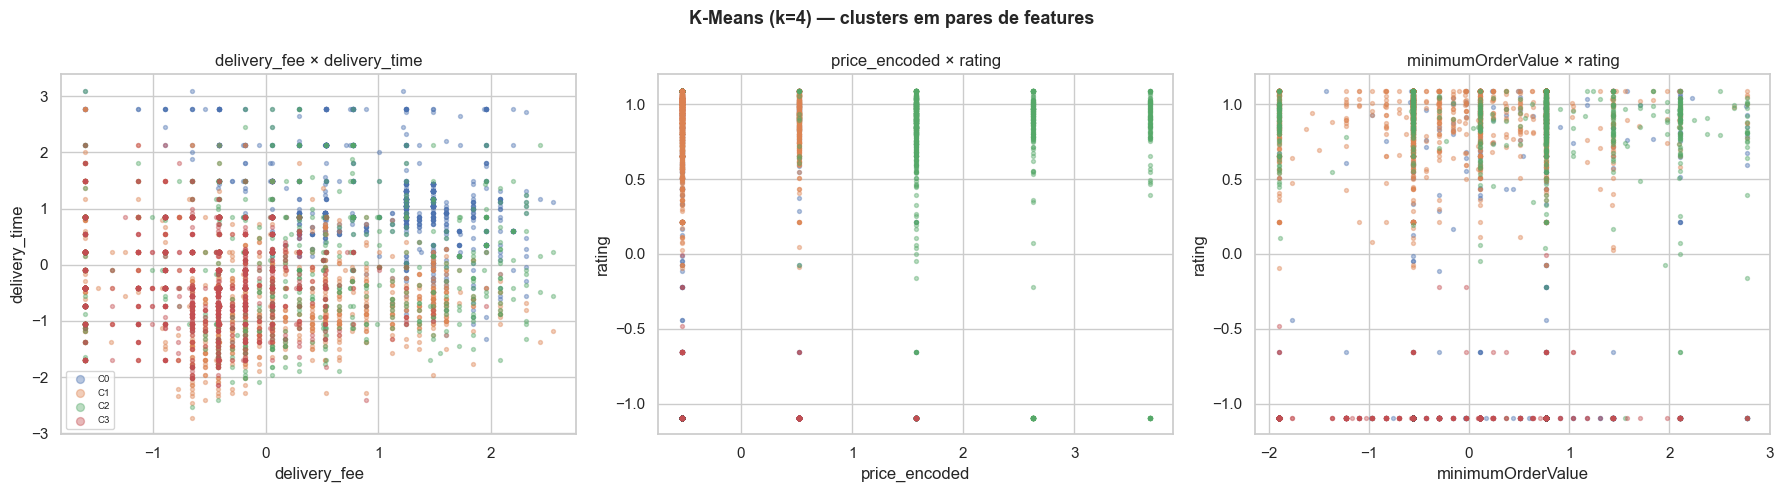

In [9]:
plot_pares(X_df, lab_kmeans, f'K-Means (k={k}) — clusters em pares de features')

O K-Means parte os dados em quatro grupos de tamanhos parecidos. Como já era esperado pela Etapa 2 (variância distribuída e correlações fracas), não há fronteiras nítidas: os grupos dividem uma nuvem contínua em vez de separar agrupamentos naturais.

## 2.2 Hierárquico / Aglomerativo

Construímos os dendrogramas com *linkage* **average** (média do grupo), que aceita as três métricas, sobre 2.000 pontos da amostra (para a árvore ficar legível). Assim dá para ver, lado a lado, como a métrica muda a estrutura das fusões.

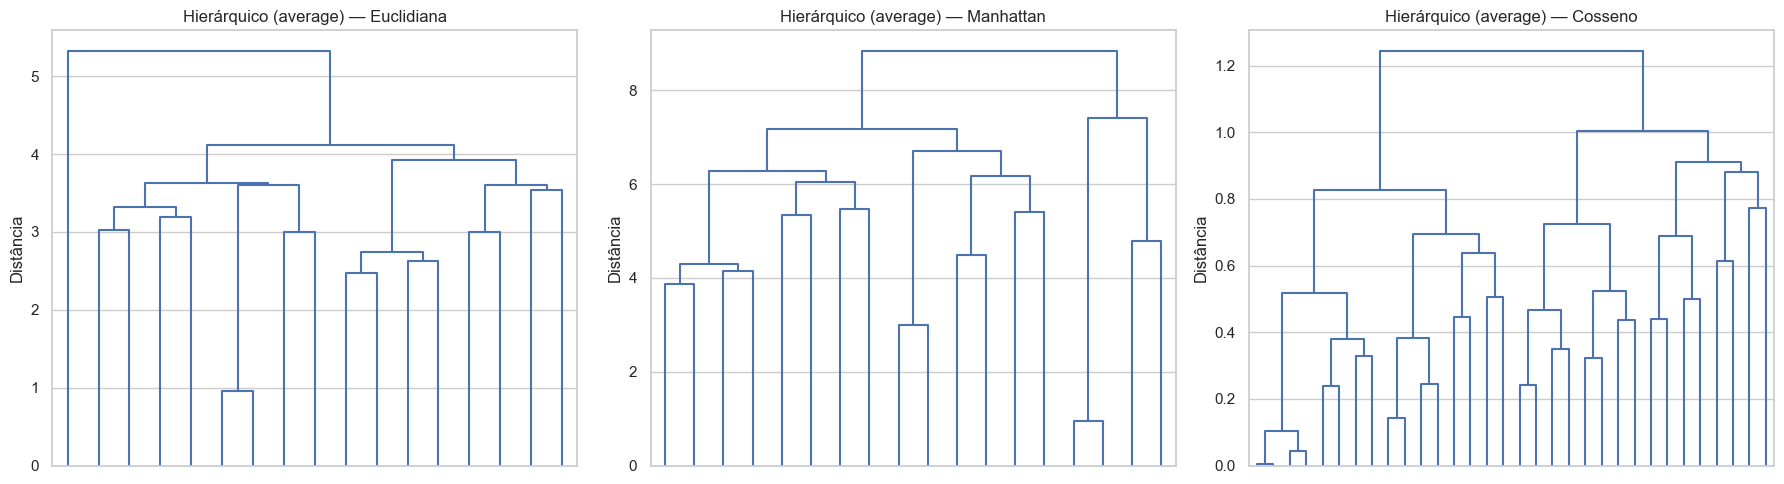

In [10]:
X_h = X_s[:2000]

# o scipy chama a métrica L1 de 'cityblock' (= Manhattan)
def metrica_scipy(m):
    return 'cityblock' if m == 'manhattan' else m


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, m) in zip(axes, METRICAS.items()):
    Z = linkage(X_h, method='average', metric=metrica_scipy(m))
    dendrogram(Z, ax=ax, truncate_mode='level', p=4, no_labels=True,
               color_threshold=0)
    ax.set_title(f'Hierárquico (average) — {nome}')
    ax.set_ylabel('Distância')
plt.tight_layout()
plt.show()

In [11]:
# Cortando cada dendrograma em 4 clusters e comparando os tamanhos
tabela = {}
for nome, m in METRICAS.items():
    Z = linkage(X_h, method='average', metric=metrica_scipy(m))
    lab = fcluster(Z, t=4, criterion='maxclust')
    tabela[nome] = pd.Series(lab).value_counts().sort_index()

pd.DataFrame(tabela).fillna(0).astype(int)

,Euclidiana,Manhattan,Cosseno
1,1853,291,856
2,24,1705,294
3,122,2,433
4,1,2,417


Com *average linkage*, as três métricas tendem ao efeito de **encadeamento** (*chaining*): um cluster gigante e alguns minúsculos. Isso reforça que os dados não têm grupos densos e bem separados.

Para obter uma partição mais equilibrada e comparável ao K-Means, usamos o *linkage* de **Ward** (que minimiza a variância intra-cluster e só funciona com a euclidiana) e cortamos em 4 grupos.

Tamanho de cada cluster (Ward, k=4):
1    349
2    550
3    291
4    810
Name: restaurantes, dtype: int64


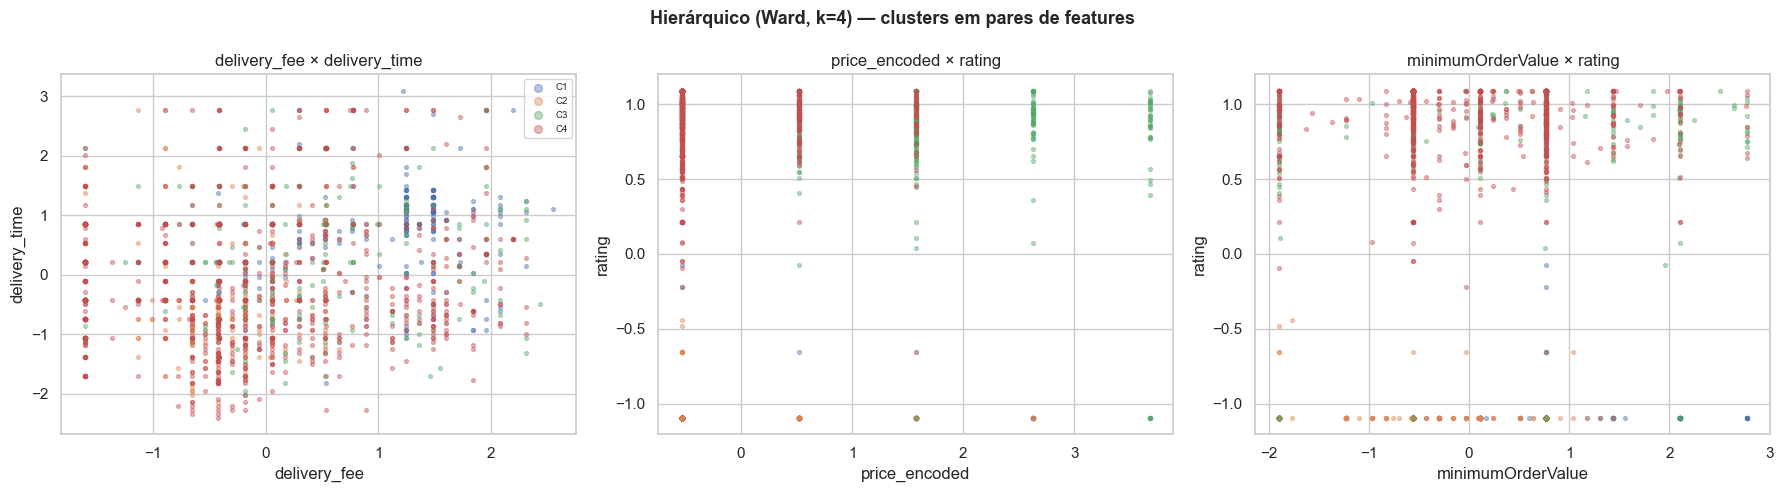

In [12]:
Z_ward = linkage(X_h, method='ward')
lab_ward = fcluster(Z_ward, t=4, criterion='maxclust')

print("Tamanho de cada cluster (Ward, k=4):")
print(pd.Series(lab_ward).value_counts().sort_index().rename('restaurantes'))

plot_pares(X_df.iloc[:2000].reset_index(drop=True), lab_ward,
           'Hierárquico (Ward, k=4) — clusters em pares de features')

O Ward produz quatro grupos de tamanhos mais próximos, com um resultado visualmente parecido com o do K-Means — coerente, já que ambos otimizam compacidade com base na distância euclidiana.

## 2.3 DBSCAN (densidade)

O DBSCAN precisa de dois parâmetros: `eps` (raio da vizinhança) e `min_samples` (mínimo de pontos para formar região densa). Fixamos `min_samples = 10` e escolhemos o `eps` pelo **gráfico de k-distância**: ordenamos a distância de cada ponto ao seu 10º vizinho e procuramos o "cotovelo".

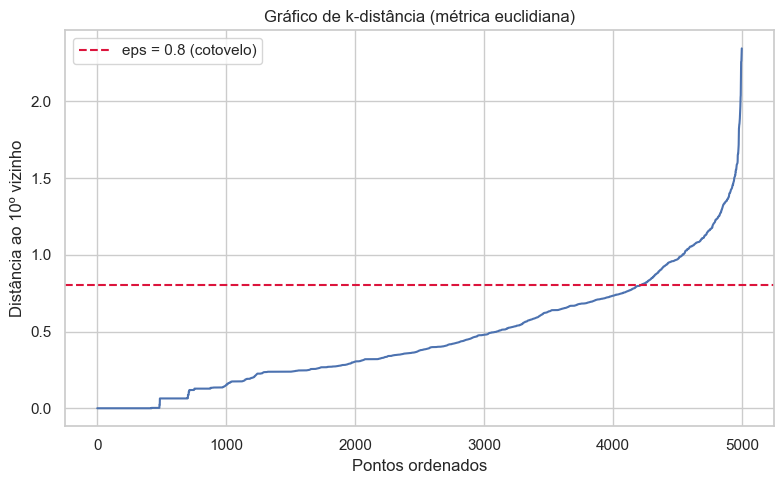

In [13]:
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_s)
dist, _ = nn.kneighbors(X_s)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.axhline(0.8, ls='--', color='crimson', label='eps = 0.8 (cotovelo)')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância ao {min_samples}º vizinho')
plt.title('Gráfico de k-distância (métrica euclidiana)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
db = DBSCAN(eps=0.8, min_samples=min_samples, metric='euclidean').fit(X_s)
lab_db = db.labels_

n_clusters = len(set(lab_db)) - (1 if -1 in lab_db else 0)
n_ruido = int((lab_db == -1).sum())
print(f"Clusters encontrados: {n_clusters}")
print(f"Pontos de ruído: {n_ruido} ({100 * n_ruido / len(lab_db):.1f}%)")
print("\nTamanho de cada cluster (-1 = ruído):")
print(pd.Series(lab_db).value_counts().sort_index().rename('restaurantes'))

Clusters encontrados: 10
Pontos de ruído: 430 (8.6%)

Tamanho de cada cluster (-1 = ruído):
-1     430
 0    3585
 1     354
 2     331
 3      75
 4      71
 5      41
 6      37
 7      43
 8      21
 9      12
Name: restaurantes, dtype: int64


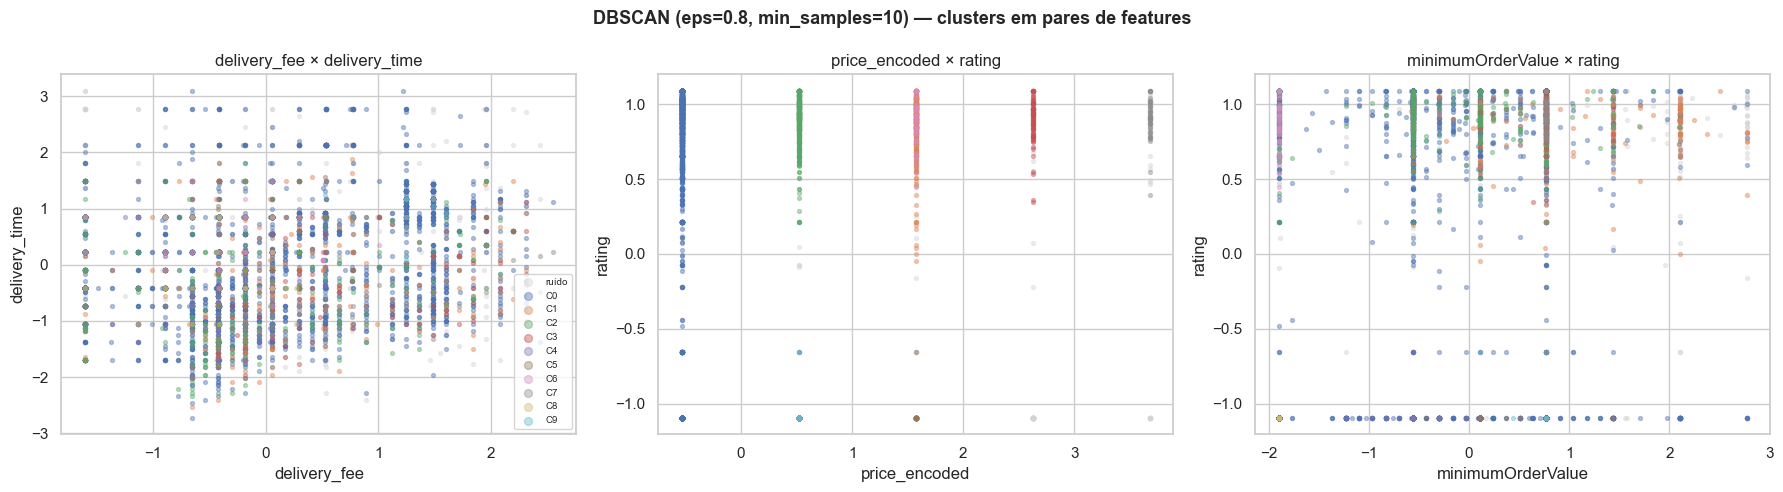

In [15]:
plot_pares(X_df, lab_db, 'DBSCAN (eps=0.8, min_samples=10) — clusters em pares de features')

Como a métrica muda a escala das distâncias, o `eps` também precisa mudar. Repetimos o DBSCAN com as três métricas, cada uma com um `eps` ajustado pela sua escala:

In [16]:
config_db = {'Euclidiana': ('euclidean', 0.8),
             'Manhattan': ('manhattan', 1.0),
             'Cosseno':   ('cosine', 0.05)}

linhas = []
for nome, (m, eps) in config_db.items():
    labels = DBSCAN(eps=eps, min_samples=min_samples, metric=m).fit_predict(X_s)
    n_clu = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int((labels == -1).sum())
    linhas.append({'métrica': nome, 'eps': eps, 'clusters': n_clu,
                   'ruído': n_ruido, 'ruído %': round(100 * n_ruido / len(labels), 1)})

pd.DataFrame(linhas).set_index('métrica')

,eps,clusters,ruído,ruído %
métrica,,,,
Euclidiana,0.80,10,430,8.6
Manhattan,1.00,17,560,11.2
Cosseno,0.05,9,240,4.8


O DBSCAN encontra vários grupos pequenos e densos e classifica o restante como ruído. A quantidade de clusters e de ruído varia bastante com a métrica e o `eps`, o que confirma que não existe uma densidade dominante única — o algoritmo está, na prática, recortando bolsões da mesma nuvem contínua.

## Comparação final dos métodos

Colocando as três abordagens lado a lado nos mesmos pares de features (colunas = métodos, linhas = pares):

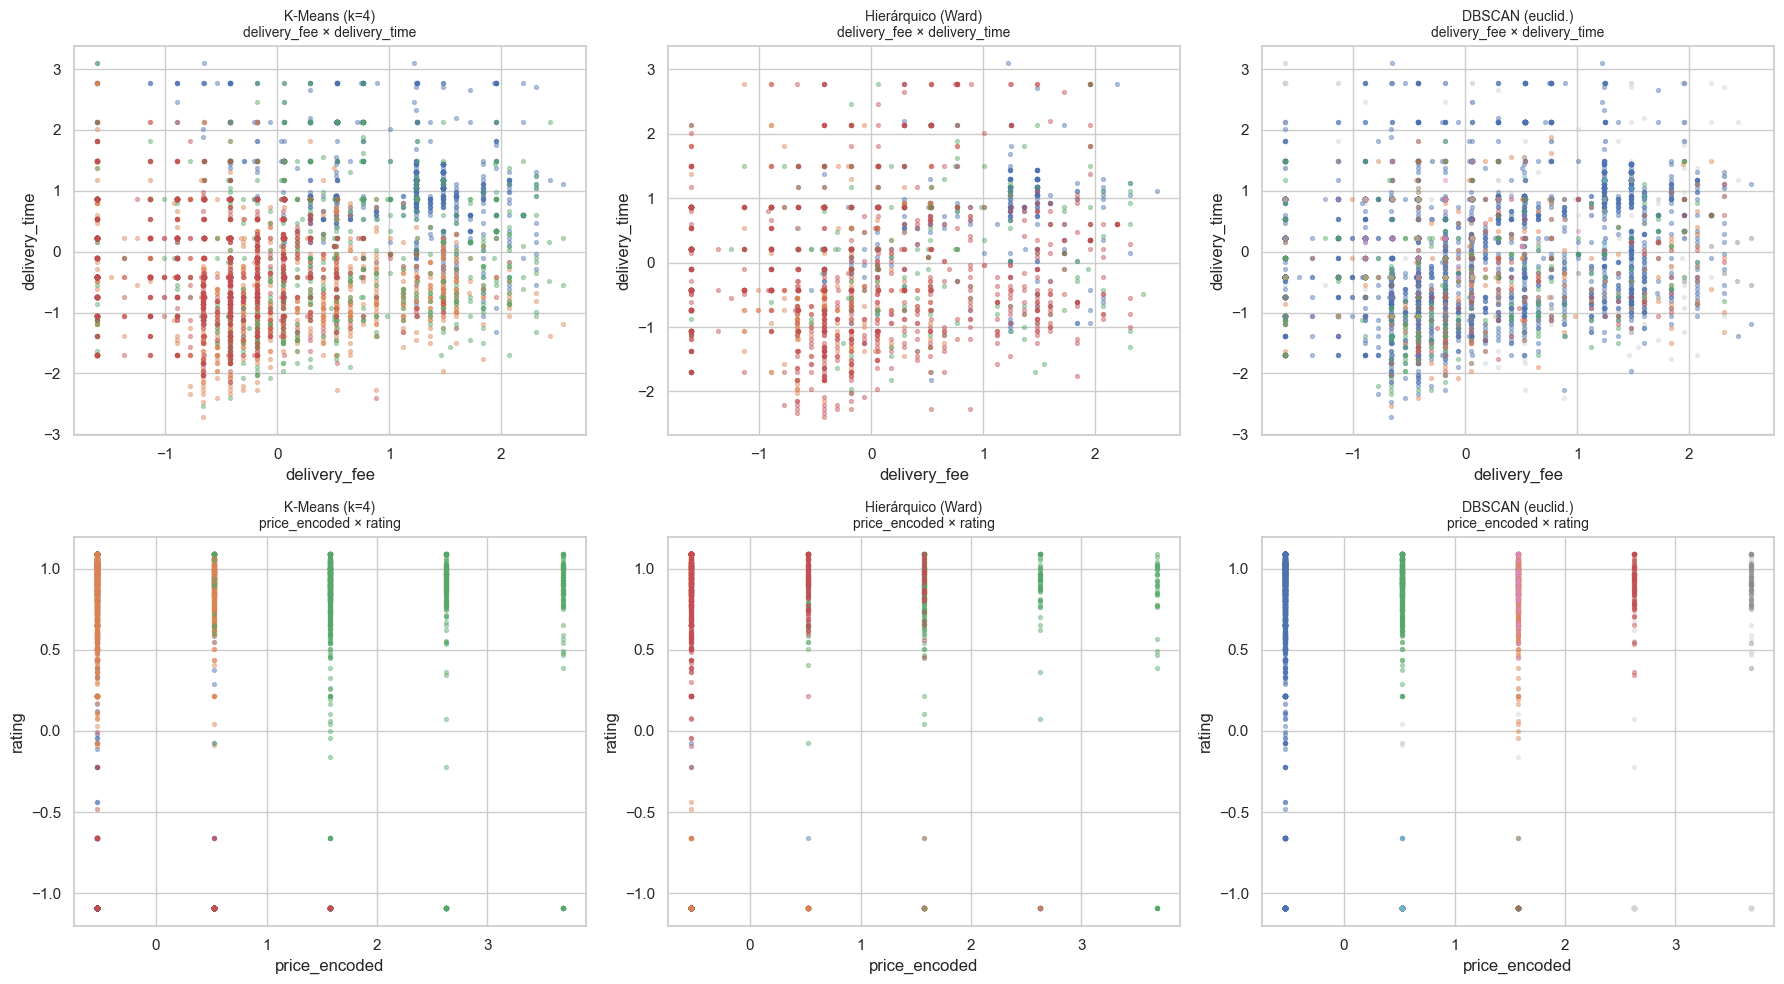

In [17]:
metodos = [('K-Means (k=4)', X_df, lab_kmeans),
           ('Hierárquico (Ward)', X_df.iloc[:2000].reset_index(drop=True), lab_ward),
           ('DBSCAN (euclid.)', X_df, lab_db)]
pares_cmp = [('delivery_fee', 'delivery_time'), ('price_encoded', 'rating')]

fig, axes = plt.subplots(len(pares_cmp), len(metodos), figsize=(18, 10))
for j, (nome, fdf, lab) in enumerate(metodos):
    for i, (fx, fy) in enumerate(pares_cmp):
        scatter_par(axes[i, j], fdf, lab, fx, fy)
        axes[i, j].set_title(f'{nome}\n{fx} × {fy}', fontsize=10)
plt.tight_layout()
plt.show()

### Conclusões desta entrega

- **Métricas.** Euclidiana e Manhattan se comportam de forma parecida (diferem na escala); o Cosseno não é adequado aqui, porque os atributos são numéricos centrados e a *orientação* dos vetores não representa o perfil do restaurante. Adotamos a **euclidiana** como referência.
- **Métodos.** K-Means e Hierárquico (Ward) produzem partições equilibradas e bem semelhantes entre si; o DBSCAN encontra muitos núcleos pequenos + ruído. Em nenhum caso surgem clusters nitidamente separados.
- Isso é **coerente com a Etapa 2**: PCA e UMAP já indicavam uma nuvem contínua, sem grupos naturais óbvios.

**Próximos passos (continuação da Etapa 3):** avaliar a qualidade dos agrupamentos com métricas de coesão e separação (silhouette, Davies-Bouldin, Calinski-Harabasz), escolher *k* via Elbow/Silhouette e testar a estabilidade dos clusters (ARI/NMI entre diferentes sementes).

In [18]:
# Imports usados a partir daqui (avaliação, elbow e UMAP)
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from scripts.utils import plot_elbow_sse
import umap.umap_ as umap

C:\Users\Marcos\Desktop\cd2-trabalho\cd2-trabalho\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parte 3 — Escolha do número de clusters (Elbow + Silhouette)

Na Parte 2 usamos `k = 4` apenas como ponto de partida. Aqui escolhemos o número de clusters de forma mais objetiva, combinando dois critérios sobre a amostra:

- **Elbow (cotovelo):** olhamos a soma dos quadrados dos erros (SSE / inércia) do K-Means para vários `k` e procuramos o ponto onde a curva "dobra".
- **Silhouette:** mede o quão bem cada ponto fica dentro do seu cluster (varia de -1 a 1; quanto maior, melhor). Usamos como referência o valor **0,25**.

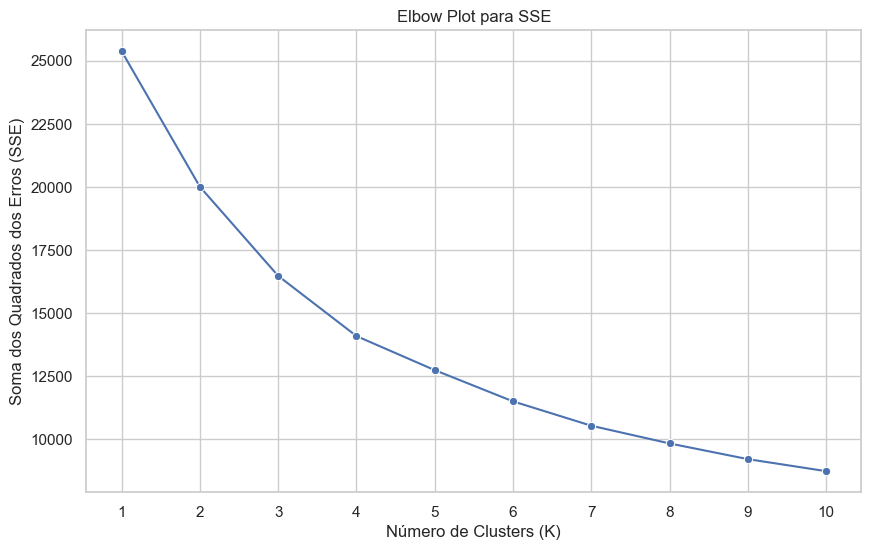

In [19]:
# SSE (inércia) do K-Means para k de 1 a 10
sse = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_s)
    sse.append(km.inertia_)

plot_elbow_sse(sse, k_range=(1, 10))

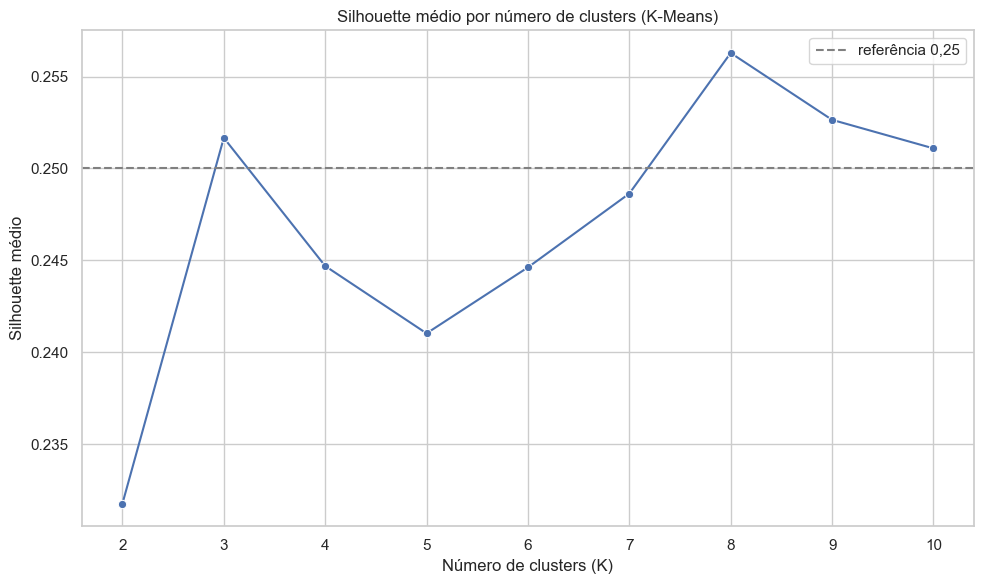

Melhor k pelo silhouette: 8 (silhouette = 0.256)


In [20]:
# Silhouette médio do K-Means para k de 2 a 10
ks = list(range(2, 11))
sil_por_k = []
for k in ks:
    lab = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_s)
    sil_por_k.append(silhouette_score(X_s, lab))

plt.figure(figsize=(10, 6))
sns.lineplot(x=ks, y=sil_por_k, marker='o')
plt.axhline(0.25, ls='--', color='gray', label='referência 0,25')
plt.title('Silhouette médio por número de clusters (K-Means)')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette médio')
plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()

k_melhor = ks[int(np.argmax(sil_por_k))]
print(f"Melhor k pelo silhouette: {k_melhor} (silhouette = {max(sil_por_k):.3f})")

A curva de SSE cai de forma suave, **sem um cotovelo nítido** — já esperado pela Etapa 2 (variância distribuída, nuvem contínua). O silhouette fica **baixo e quase plano** em todos os valores (entre ~0,23 e ~0,26), confirmando que não há grupos bem separados. O máximo acontece em **k = 8** (silhouette ≈ 0,256), logo acima da referência de 0,25.

Adotamos **k = 8** como escolha formal: é o valor com melhor silhouette (e que ainda atinge a referência), dando a segmentação mais detalhada. Vale registrar que a estrutura é fraca — os critérios não apontam um número de clusters "óbvio".

# Parte 4 — Avaliação e comparação dos agrupamentos

Avaliamos a qualidade dos agrupamentos com três métricas internas (não precisam de rótulo verdadeiro):

- **Silhouette** — coesão vs. separação (maior = melhor; referência ≥ 0,25);
- **Davies-Bouldin** — razão de dispersão dentro/entre clusters (menor = melhor);
- **Calinski-Harabasz** — razão de variância entre/dentro dos clusters (maior = melhor).

Comparamos primeiro diferentes `k`, depois os três métodos e, por fim, as três métricas de distância.

### 4.1 Comparação entre diferentes k (K-Means)

In [21]:
# Métricas internas do K-Means para diferentes k
linhas = []
for k in range(2, 7):
    lab = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_s)
    linhas.append({'k': k,
                   'silhouette': silhouette_score(X_s, lab),
                   'davies_bouldin': davies_bouldin_score(X_s, lab),
                   'calinski_harabasz': calinski_harabasz_score(X_s, lab)})

pd.DataFrame(linhas).set_index('k').round(3)

,silhouette,davies_bouldin,calinski_harabasz
k,,,
2,0.232,1.767,1341.726
3,0.252,1.578,1349.696
4,0.245,1.372,1333.523
5,0.241,1.393,1237.964
6,0.245,1.272,1204.156


O silhouette fica em torno de 0,24–0,25 para todos os `k`, o Davies-Bouldin melhora (cai) conforme `k` aumenta e o Calinski-Harabasz é maior para poucos clusters. Nenhum `k` se destaca de forma clara — coerente com a ausência de grupos naturais.

### 4.2 Comparação entre os três métodos (no k escolhido)

In [22]:
# Comparação dos três métodos no k escolhido.
# Ward é avaliado em 2.000 pontos por causa do custo O(n²), como na Parte 2;
# no DBSCAN o silhouette ignora os pontos de ruído (-1).
lab_km_best = KMeans(n_clusters=k_melhor, random_state=SEED, n_init=10).fit_predict(X_s)

Z_ward = linkage(X_s[:2000], method='ward')
lab_ward_best = fcluster(Z_ward, t=k_melhor, criterion='maxclust')

lab_db_best = DBSCAN(eps=0.8, min_samples=10, metric='euclidean').fit_predict(X_s)
m_db = lab_db_best != -1   # máscara que remove o ruído

linhas = [
    {'método': f'K-Means (k={k_melhor})', 'n': len(X_s),
     'silhouette': silhouette_score(X_s, lab_km_best),
     'davies_bouldin': davies_bouldin_score(X_s, lab_km_best),
     'calinski_harabasz': calinski_harabasz_score(X_s, lab_km_best)},
    {'método': f'Ward (k={k_melhor})', 'n': 2000,
     'silhouette': silhouette_score(X_s[:2000], lab_ward_best),
     'davies_bouldin': davies_bouldin_score(X_s[:2000], lab_ward_best),
     'calinski_harabasz': calinski_harabasz_score(X_s[:2000], lab_ward_best)},
    {'método': 'DBSCAN (sem ruído)', 'n': int(m_db.sum()),
     'silhouette': silhouette_score(X_s[m_db], lab_db_best[m_db]),
     'davies_bouldin': davies_bouldin_score(X_s[m_db], lab_db_best[m_db]),
     'calinski_harabasz': calinski_harabasz_score(X_s[m_db], lab_db_best[m_db])},
]
pd.DataFrame(linhas).set_index('método').round(3)

,n,silhouette,davies_bouldin,calinski_harabasz
método,,,,
K-Means (k=8),5000,0.256,1.195,1126.188
Ward (k=8),2000,0.179,1.491,330.387
DBSCAN (sem ruído),4570,-0.133,1.767,158.461


O **K-Means** tem o melhor silhouette e o melhor Davies-Bouldin. O **Ward** fica abaixo (avaliado em 2.000 pontos). O **DBSCAN** tem silhouette **negativo** — os grupos de densidade que ele encontra se sobrepõem na prática, confirmando que ele está recortando bolsões de uma nuvem contínua. O K-Means é, portanto, o método mais adequado aqui.

### 4.3 Comparação entre as três métricas de distância (hierárquico)

In [23]:
# Silhouette do hierárquico (average linkage) com cada métrica, no k escolhido
# (average linkage aceita as três métricas; usamos 2.000 pontos pelo custo O(n²))
linhas = []
for nome, m in METRICAS.items():
    Z = linkage(X_s[:2000], method='average', metric=metrica_scipy(m))
    lab = fcluster(Z, t=k_melhor, criterion='maxclust')
    n_clu = len(set(lab))
    sil = silhouette_score(X_s[:2000], lab, metric=m) if n_clu > 1 else np.nan
    linhas.append({'métrica': nome, 'clusters': n_clu, 'silhouette': sil})

pd.DataFrame(linhas).set_index('métrica').round(3)

,clusters,silhouette
métrica,,
Euclidiana,8,0.129
Manhattan,8,0.097
Cosseno,8,0.314


O **cosseno** dá um silhouette aparentemente maior, mas esse valor é medido no próprio espaço do cosseno — e, como vimos na Parte 1, a orientação dos vetores não representa o perfil do restaurante (atributos numéricos centrados). Euclidiana e Manhattan ficam baixas, e o average linkage ainda sofre com o encadeamento. Mantemos a **Euclidiana** como métrica de referência.

# Parte 5 — Estabilidade do K-Means (ARI / NMI entre sementes)

O K-Means depende da inicialização aleatória dos centróides. Para checar se a partição é estável, rodamos o algoritmo com cinco sementes diferentes (`[0, 1, 2, 42, 100]`) e comparamos as partições par a par com duas métricas de concordância:

- **ARI (Adjusted Rand Index)** e **NMI (Normalized Mutual Information)** — ambas variam de 0 (concordância aleatória) a 1 (partições idênticas). Alvo ideal: **ARI > 0,8**.

In [24]:
# K-Means com várias sementes, comparando as partições par a par
seeds = [0, 1, 2, 42, 100]
labels_seeds = {s: KMeans(n_clusters=k_melhor, random_state=s, n_init=10).fit_predict(X_s)
                for s in seeds}

linhas = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        a, b = seeds[i], seeds[j]
        linhas.append({'par': f'{a} vs {b}',
                       'ARI': adjusted_rand_score(labels_seeds[a], labels_seeds[b]),
                       'NMI': normalized_mutual_info_score(labels_seeds[a], labels_seeds[b])})

tab_estab = pd.DataFrame(linhas).set_index('par').round(3)
print(f"ARI médio: {tab_estab['ARI'].mean():.3f}  |  NMI médio: {tab_estab['NMI'].mean():.3f}")
tab_estab

ARI médio: 0.905  |  NMI médio: 0.899


,ARI,NMI
par,,
0 vs 1,0.958,0.944
0 vs 2,0.992,0.986
0 vs 42,0.820,0.821
0 vs 100,0.947,0.933
1 vs 2,0.958,0.945
1 vs 42,0.814,0.815
1 vs 100,0.975,0.965
2 vs 42,0.824,0.826
2 vs 100,0.949,0.934


Todos os pares ficam com **ARI acima de 0,8** (média ≈ 0,90), com NMI semelhante. Apesar do silhouette baixo, a partição do K-Means é **estável** entre as sementes: mesmo sem grupos nitidamente separados, o algoritmo converge praticamente para a mesma divisão da nuvem.

# Parte 6 — Visualização dos clusters em 2D (UMAP)

Para enxergar os clusters em duas dimensões, reaproveitamos o **UMAP** da Etapa 2 (mesmos parâmetros: `n_components=2`, `metric='euclidean'`, `random_state=42`, `n_neighbors=15`, `min_dist=0.1`). Como os rótulos foram calculados sobre a amostra `X_s`, recalculamos o embedding sobre essa mesma amostra para os pontos ficarem alinhados aos clusters.

In [25]:
# Recalcula o embedding UMAP 2D sobre a amostra X_s (mesmos parâmetros da Etapa 2)
redutor = umap.UMAP(n_components=2, metric='euclidean', random_state=SEED,
                    n_neighbors=15, min_dist=0.1)
emb = redutor.fit_transform(X_s)
print(f"Embedding UMAP: {emb.shape[0]:,} pontos × {emb.shape[1]} dimensões")

C:\Users\Marcos\Desktop\cd2-trabalho\cd2-trabalho\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding UMAP: 5,000 pontos × 2 dimensões


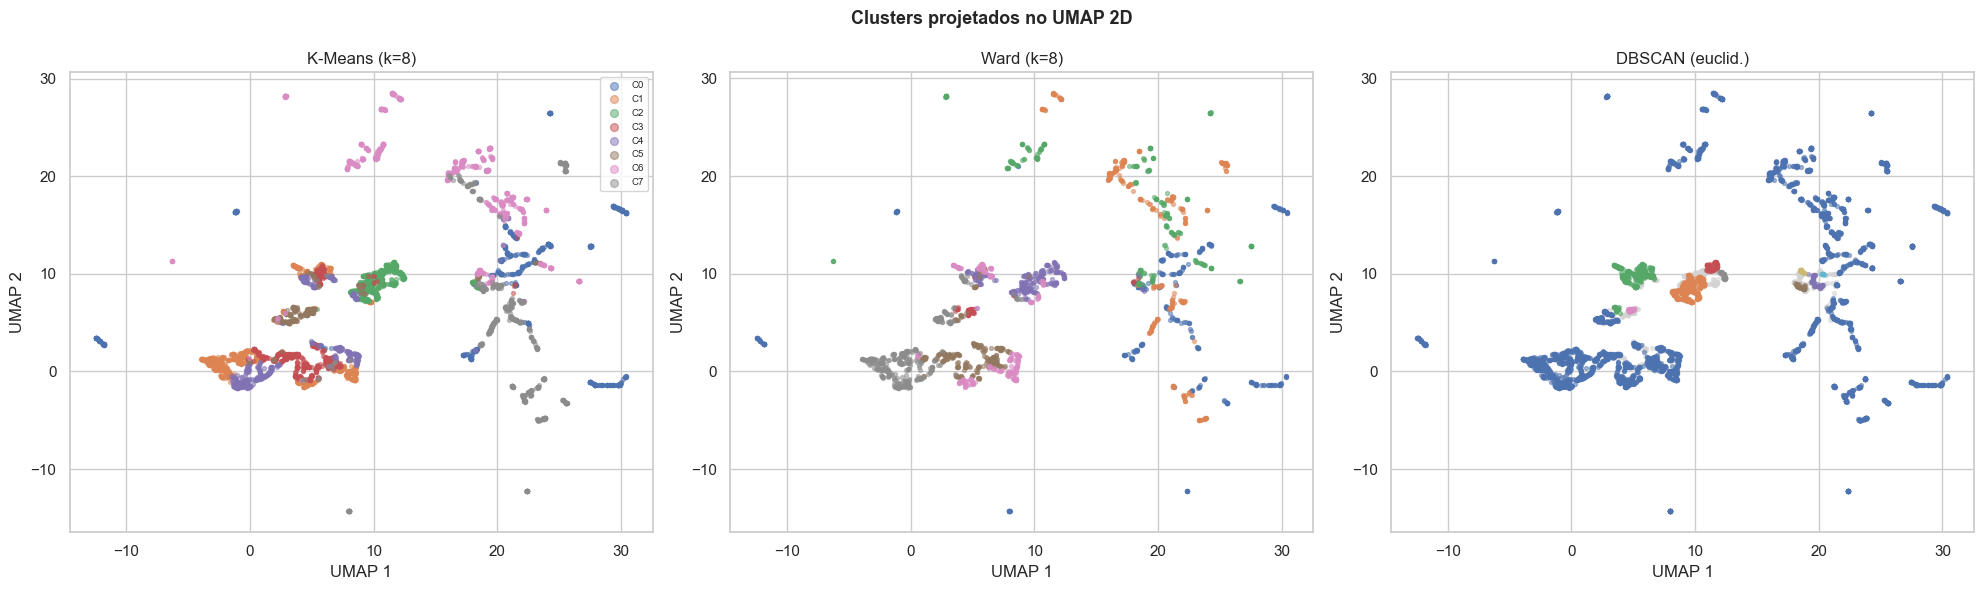

In [26]:
# Projeção dos clusters no UMAP, lado a lado (K-Means, Ward e DBSCAN)
def scatter_umap(ax, emb2d, labels, titulo):
    for u in np.unique(labels):
        m = labels == u
        cor = 'lightgray' if u == -1 else None
        nome = 'ruído' if u == -1 else f'C{u}'
        ax.scatter(emb2d[m, 0], emb2d[m, 1], s=8, alpha=0.5, label=nome, c=cor)
    ax.set_title(titulo)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
scatter_umap(axes[0], emb, lab_km_best, f'K-Means (k={k_melhor})')
scatter_umap(axes[1], emb[:2000], lab_ward_best, f'Ward (k={k_melhor})')
scatter_umap(axes[2], emb, lab_db_best, 'DBSCAN (euclid.)')
axes[0].legend(markerscale=2, fontsize=7, loc='best')
fig.suptitle('Clusters projetados no UMAP 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

No UMAP os pontos formam uma **mancha contínua**, sem vazios separando grupos. O K-Means divide essa mancha em regiões vizinhas e coerentes; o Ward produz uma divisão parecida; o DBSCAN espalha o ruído (cinza) pelas bordas. Isso reforça a leitura da Etapa 2: não há grupos naturais isolados, e os clusters são uma **partição útil** de uma distribuição contínua.

# Parte 7 — Interpretação dos clusters

In [27]:
# Perfil de cada cluster do K-Means: média de cada feature (em z-score)
kmeans_final = KMeans(n_clusters=k_melhor, random_state=SEED, n_init=10).fit(X_s)

perfil = pd.DataFrame(kmeans_final.cluster_centers_, columns=col_modelo)
perfil['tamanho'] = pd.Series(kmeans_final.labels_).value_counts().sort_index()
perfil.round(2)

,delivery_fee,delivery_time,minimumOrderValue,rating,price_encoded,tamanho
0,0.96,1.08,0.22,-1.04,-0.41,731
1,-0.43,-1.00,-0.18,0.92,-0.30,804
2,0.20,-0.12,0.86,0.69,2.18,597
3,-0.67,0.83,0.37,0.88,-0.33,618
4,1.39,-0.05,-0.04,0.91,-0.26,519
5,-0.21,0.76,-1.72,0.71,0.67,271
6,-0.57,-0.18,-1.04,-1.08,-0.43,811
7,-0.48,-0.40,0.78,-1.07,-0.38,649


In [28]:
# price_encoded de volta à escala original (1 a 5) para facilitar a leitura
centros_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
preco_medio = pd.Series(centros_orig[:, col_modelo.index('price_encoded')]).round(2)
print("price_encoded médio por cluster (escala 1-5):")
print(preco_medio.to_dict())

# Anexa o cluster à amostra (sem alterar info_s original) e cruza com a faixa de preço
info_clusters = info_s.copy()
info_clusters['cluster'] = kmeans_final.labels_
pd.crosstab(info_clusters['cluster'], info_clusters['price_range'])

price_encoded médio por cluster (escala 1-5):
{0: 1.11, 1: 1.22, 2: 3.57, 3: 1.2, 4: 1.26, 5: 2.14, 6: 1.1, 7: 1.15}


price_range,CHEAP,CHEAPEST,EXPENSIVE,MODERATE,MOST_EXPENSIVE
cluster,,,,,
0,36,672,0,23,0
1,131,650,0,23,0
2,3,0,162,341,91
3,107,504,0,7,0
4,82,410,0,27,0
5,58,106,19,78,10
6,49,745,0,17,0
7,49,577,0,23,0


In [29]:
# Cruzamento com a categoria (usada só para interpretar; não entrou no modelo)
pd.crosstab(info_clusters['cluster'], info_clusters['category_grouped'])

category_grouped,Açaí,Bebidas,Brasileira,Doces & Bolos,Japonesa,Lanches,Marmita,Outros,Pizza,Salgados,Saudável
cluster,,,,,,,,,,,
0,36,23,154,107,15,179,33,112,40,23,9
1,82,27,142,100,7,182,39,156,28,16,25
2,2,14,100,11,68,89,2,151,141,4,15
3,40,6,96,32,24,207,27,99,63,16,8
4,36,13,96,75,16,104,28,93,33,8,17
5,9,7,39,14,12,102,3,34,42,5,4
6,66,37,102,142,6,186,67,107,44,14,40
7,8,14,183,16,13,204,8,97,73,26,7


**Leitura dos clusters.** Os perfis acima estão em z-score (0 = média da amostra; positivo = acima da média, negativo = abaixo). Os dois eixos que mais separam os grupos são a **avaliação** (`rating`) e a **faixa de preço** (`price_encoded`); a logística de entrega (taxa, tempo, pedido mínimo) refina os subgrupos:

- **C2 — premium:** único grupo de preço alto (`price_encoded` ≈ 3,6, concentra `EXPENSIVE`/`MOST_EXPENSIVE`), pedido mínimo alto e boa avaliação.
- **Bem avaliados e comuns (preço baixo):** C1 (entrega rápida e barata), C3 (entrega barata mas lenta), C4 (taxa de entrega alta) e C5 (pedido mínimo muito baixo) — todos com `rating` acima da média.
- **Ainda sem avaliação** (`rating` bem abaixo da média, reflexo dos ~44% com nota 0 vistos na Etapa 1): C0 (entrega cara e lenta), C6 (barato e pedido mínimo baixo) e C7 (pedido mínimo alto).

O cruzamento com `category_grouped` fica distribuído de forma parecida entre os clusters, ou seja, a **categoria culinária não é o que separa os grupos** — por isso ela ficou de fora do modelo (alta cardinalidade) e serve só para descrever os resultados.

**Justificativas das escolhas.**
- **Algoritmo (K-Means):** teve o melhor silhouette e Davies-Bouldin, gera partições equilibradas, é escalável e **estável** (ARI médio ≈ 0,90); o Ward concorda com ele e o DBSCAN não se aplica bem (silhouette negativo).
- **Número de clusters (k = 8):** maior silhouette (ainda ≥ 0,25), dando a segmentação mais detalhada; valores menores de `k` dariam grupos mais grosseiros sem ganho real de separação.
- **Variáveis:** as 5 numéricas selecionadas na Etapa 2 (`delivery_fee`, `delivery_time`, `minimumOrderValue`, `rating`, `price_encoded`), padronizadas para ficarem na mesma escala; `category` ficou de fora pelos motivos acima.

# Conclusão final da Etapa 3

Aplicamos e comparamos três famílias de algoritmos (K-Means, Hierárquico/Ward e DBSCAN) sobre as 5 variáveis numéricas selecionadas na Etapa 2, testando as distâncias Euclidiana, Manhattan e Cosseno.

- A **Euclidiana** é a métrica de referência; o cosseno não é adequado para atributos numéricos centrados.
- A escolha de `k` por **Elbow + Silhouette** levou a **k = 8**, com silhouette ≈ 0,26 (acima da referência de 0,25) — mas a estrutura é fraca: os dados formam uma **nuvem contínua**, sem grupos naturais, coerente com o PCA/UMAP da Etapa 2.
- O **K-Means** foi o melhor método (melhores silhouette e Davies-Bouldin) e **estável** (ARI médio ≈ 0,90 entre sementes, acima do alvo de 0,8); o DBSCAN teve silhouette negativo e o Ward ficou abaixo.
- Os 8 clusters se diferenciam principalmente por **avaliação** (com nota vs. ainda sem avaliação) e **faixa de preço** (um grupo premium isolado), com a logística de entrega refinando os subgrupos.

Em resumo: mesmo sem agrupamentos nitidamente separados, o K-Means com `k = 8` entrega uma segmentação **estável e interpretável** dos restaurantes do iFood.